In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

Data Cleaning

In [2]:
df=pd.read_csv("/content/drive/MyDrive/RGU CWII/AmesHousing.csv")
print(f"Raw shape: {df.shape}")

Raw shape: (2930, 82)


In [3]:
# checking the first few rows of the dataset
df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


In [4]:
# checking the columns available in the dataset
df.columns.tolist()

['Order',
 'PID',
 'MS SubClass',
 'MS Zoning',
 'Lot Frontage',
 'Lot Area',
 'Street',
 'Alley',
 'Lot Shape',
 'Land Contour',
 'Utilities',
 'Lot Config',
 'Land Slope',
 'Neighborhood',
 'Condition 1',
 'Condition 2',
 'Bldg Type',
 'House Style',
 'Overall Qual',
 'Overall Cond',
 'Year Built',
 'Year Remod/Add',
 'Roof Style',
 'Roof Matl',
 'Exterior 1st',
 'Exterior 2nd',
 'Mas Vnr Type',
 'Mas Vnr Area',
 'Exter Qual',
 'Exter Cond',
 'Foundation',
 'Bsmt Qual',
 'Bsmt Cond',
 'Bsmt Exposure',
 'BsmtFin Type 1',
 'BsmtFin SF 1',
 'BsmtFin Type 2',
 'BsmtFin SF 2',
 'Bsmt Unf SF',
 'Total Bsmt SF',
 'Heating',
 'Heating QC',
 'Central Air',
 'Electrical',
 '1st Flr SF',
 '2nd Flr SF',
 'Low Qual Fin SF',
 'Gr Liv Area',
 'Bsmt Full Bath',
 'Bsmt Half Bath',
 'Full Bath',
 'Half Bath',
 'Bedroom AbvGr',
 'Kitchen AbvGr',
 'Kitchen Qual',
 'TotRms AbvGrd',
 'Functional',
 'Fireplaces',
 'Fireplace Qu',
 'Garage Type',
 'Garage Yr Blt',
 'Garage Finish',
 'Garage Cars',
 'Garage 

In [5]:
# #Order and parcel ID(PID) do not contain information relevant to housing. Therefore, Order and PID columns are dropped.
df.drop(columns=['Order', 'PID'], inplace=True)
print(df.shape)

(2930, 80)


In [6]:
# datatype of each column
print(df.dtypes)

MS SubClass         int64
MS Zoning          object
Lot Frontage      float64
Lot Area            int64
Street             object
                   ...   
Mo Sold             int64
Yr Sold             int64
Sale Type          object
Sale Condition     object
SalePrice           int64
Length: 80, dtype: object


In [7]:
# Statistical analysis of numeric columns
df.describe()

,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,BsmtFin SF 1,BsmtFin SF 2,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
count,2930.000000,2440.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2907.000000,2929.000000,2929.000000,...,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000,2930.000000
mean,57.387372,69.224590,10147.921843,6.094881,5.563140,1971.356314,1984.266553,101.896801,442.629566,49.722431,...,93.751877,47.533447,23.011604,2.592491,16.002048,2.243345,50.635154,6.216041,2007.790444,180796.060068
std,42.638025,23.365335,7880.017759,1.411026,1.111537,30.245361,20.860286,179.112611,455.590839,169.168476,...,126.361562,67.483400,64.139059,25.141331,56.087370,35.597181,566.344288,2.714492,1.316613,79886.692357
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,12789.000000
25%,20.000000,58.000000,7440.250000,5.000000,5.000000,1954.000000,1965.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129500.000000
50%,50.000000,68.000000,9436.500000,6.000000,5.000000,1973.000000,1993.000000,0.000000,370.000000,0.000000,...,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,160000.000000
75%,70.000000,80.000000,11555.250000,7.000000,6.000000,2001.000000,2004.000000,164.000000,734.000000,0.000000,...,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,213500.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,...,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [8]:
# Unique values of each categorical columns
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")
    print()

MS Zoning: ['RL' 'RH' 'FV' 'RM' 'C (all)' 'I (all)' 'A (agr)']

Street: ['Pave' 'Grvl']

Alley: [nan 'Pave' 'Grvl']

Lot Shape: ['IR1' 'Reg' 'IR2' 'IR3']

Land Contour: ['Lvl' 'HLS' 'Bnk' 'Low']

Utilities: ['AllPub' 'NoSewr' 'NoSeWa']

Lot Config: ['Corner' 'Inside' 'CulDSac' 'FR2' 'FR3']

Land Slope: ['Gtl' 'Mod' 'Sev']

Neighborhood: ['NAmes' 'Gilbert' 'StoneBr' 'NWAmes' 'Somerst' 'BrDale' 'NPkVill'
 'NridgHt' 'Blmngtn' 'NoRidge' 'SawyerW' 'Sawyer' 'Greens' 'BrkSide'
 'OldTown' 'IDOTRR' 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor'
 'Blueste' 'Mitchel' 'Timber' 'MeadowV' 'Veenker' 'GrnHill' 'Landmrk']

Condition 1: ['Norm' 'Feedr' 'PosN' 'RRNe' 'RRAe' 'Artery' 'PosA' 'RRAn' 'RRNn']

Condition 2: ['Norm' 'Feedr' 'PosA' 'PosN' 'Artery' 'RRNn' 'RRAe' 'RRAn']

Bldg Type: ['1Fam' 'TwnhsE' 'Twnhs' 'Duplex' '2fmCon']

House Style: ['1Story' '2Story' '1.5Fin' 'SFoyer' 'SLvl' '2.5Unf' '1.5Unf' '2.5Fin']

Roof Style: ['Hip' 'Gable' 'Mansard' 'Gambrel' 'Shed' 'Flat']

Roof Matl: ['CompShg' '

In [9]:
# Removing spaces using the strip function
str_cols = df.select_dtypes(include='object').columns
df[str_cols] = df[str_cols].apply(lambda col: col.str.strip())

# Confirm after removing spaces
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")
    print()

MS Zoning: ['RL' 'RH' 'FV' 'RM' 'C (all)' 'I (all)' 'A (agr)']

Street: ['Pave' 'Grvl']

Alley: [nan 'Pave' 'Grvl']

Lot Shape: ['IR1' 'Reg' 'IR2' 'IR3']

Land Contour: ['Lvl' 'HLS' 'Bnk' 'Low']

Utilities: ['AllPub' 'NoSewr' 'NoSeWa']

Lot Config: ['Corner' 'Inside' 'CulDSac' 'FR2' 'FR3']

Land Slope: ['Gtl' 'Mod' 'Sev']

Neighborhood: ['NAmes' 'Gilbert' 'StoneBr' 'NWAmes' 'Somerst' 'BrDale' 'NPkVill'
 'NridgHt' 'Blmngtn' 'NoRidge' 'SawyerW' 'Sawyer' 'Greens' 'BrkSide'
 'OldTown' 'IDOTRR' 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor'
 'Blueste' 'Mitchel' 'Timber' 'MeadowV' 'Veenker' 'GrnHill' 'Landmrk']

Condition 1: ['Norm' 'Feedr' 'PosN' 'RRNe' 'RRAe' 'Artery' 'PosA' 'RRAn' 'RRNn']

Condition 2: ['Norm' 'Feedr' 'PosA' 'PosN' 'Artery' 'RRNn' 'RRAe' 'RRAn']

Bldg Type: ['1Fam' 'TwnhsE' 'Twnhs' 'Duplex' '2fmCon']

House Style: ['1Story' '2Story' '1.5Fin' 'SFoyer' 'SLvl' '2.5Unf' '1.5Unf' '2.5Fin']

Roof Style: ['Hip' 'Gable' 'Mansard' 'Gambrel' 'Shed' 'Flat']

Roof Matl: ['CompShg' '

In [10]:
# Checking the unique values of the MS Subclass
print(df['MS SubClass'].unique())

[ 20  60 120  50  85 160  80  30  90 190  45  70  75  40 180 150]


In [11]:
# Converting the type of the MS Subclass to string
df['MS SubClass'] = df['MS SubClass'].astype(str)
print(df['MS SubClass'].dtype)
print(df['MS SubClass'].unique())

object
['20' '60' '120' '50' '85' '160' '80' '30' '90' '190' '45' '70' '75' '40'
 '180' '150']


In [12]:
# re-checking the shape of the dataset
df.shape

(2930, 80)

In [13]:
# Checking missing values
print(df.isnull().sum()[df.isnull().sum() > 0])

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64


In [14]:
# Drop rows where these single-missing-value columns are null
single_missing = ['BsmtFin SF 1', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Bsmt Full Bath', 'Bsmt Half Bath',
                  'Total Bsmt SF', 'Electrical', 'Garage Cars', 'Garage Area']

df = df.dropna(subset=single_missing)

print(df.shape)
print(df.isnull().sum()[df.isnull().sum() > 0])

(2926, 80)
Lot Frontage       490
Alley             2728
Mas Vnr Type      1771
Mas Vnr Area        23
Bsmt Qual           78
Bsmt Cond           78
Bsmt Exposure       81
BsmtFin Type 1      78
BsmtFin Type 2      79
Fireplace Qu      1419
Garage Type        157
Garage Yr Blt      158
Garage Finish      158
Garage Qual        158
Garage Cond        158
Pool QC           2913
Fence             2356
Misc Feature      2820
dtype: int64


In [15]:
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

Pool QC           2913
Misc Feature      2820
Alley             2728
Fence             2356
Mas Vnr Type      1771
Fireplace Qu      1419
Lot Frontage       490
Garage Yr Blt      158
Garage Qual        158
Garage Finish      158
Garage Cond        158
Garage Type        157
Bsmt Exposure       81
BsmtFin Type 2      79
Bsmt Cond           78
BsmtFin Type 1      78
Bsmt Qual           78
Mas Vnr Area        23
dtype: int64


In [16]:
fill_none = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Fireplace Qu',
             'Mas Vnr Type', 'Garage Type', 'Garage Finish', 'Garage Qual',
             'Garage Cond', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure',
             'BsmtFin Type 1', 'BsmtFin Type 2']

df[fill_none] = df[fill_none].fillna('None')

print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

Lot Frontage     490
Garage Yr Blt    158
Mas Vnr Area      23
dtype: int64


In [17]:
# No feature = 0
df['Mas Vnr Area'] = df['Mas Vnr Area'].fillna(0)
df['Garage Yr Blt'] = df['Garage Yr Blt'].fillna(0)

# Lot Frontage = median of same neighbourhood
df['Lot Frontage'] = df.groupby('Neighborhood')['Lot Frontage']\
                       .transform(lambda x: x.fillna(x.median()))

# Check
print(df.isnull().sum()[df.isnull().sum() > 0])

Lot Frontage    3
dtype: int64


In [18]:
df['Lot Frontage'] = df['Lot Frontage'].fillna(df['Lot Frontage'].median())

# Final check - should be empty (no missing values at all)
print(df.isnull().sum().sum())

0


In [19]:
print(f"Shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Columns remaining: {df.columns.tolist()}")

Shape: (2926, 80)
Missing values: 0
Columns remaining: ['MS SubClass', 'MS Zoning', 'Lot Frontage', 'Lot Area', 'Street', 'Alley', 'Lot Shape', 'Land Contour', 'Utilities', 'Lot Config', 'Land Slope', 'Neighborhood', 'Condition 1', 'Condition 2', 'Bldg Type', 'House Style', 'Overall Qual', 'Overall Cond', 'Year Built', 'Year Remod/Add', 'Roof Style', 'Roof Matl', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Mas Vnr Area', 'Exter Qual', 'Exter Cond', 'Foundation', 'Bsmt Qual', 'Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin SF 1', 'BsmtFin Type 2', 'BsmtFin SF 2', 'Bsmt Unf SF', 'Total Bsmt SF', 'Heating', 'Heating QC', 'Central Air', 'Electrical', '1st Flr SF', '2nd Flr SF', 'Low Qual Fin SF', 'Gr Liv Area', 'Bsmt Full Bath', 'Bsmt Half Bath', 'Full Bath', 'Half Bath', 'Bedroom AbvGr', 'Kitchen AbvGr', 'Kitchen Qual', 'TotRms AbvGrd', 'Functional', 'Fireplaces', 'Fireplace Qu', 'Garage Type', 'Garage Yr Blt', 'Garage Finish', 'Garage Cars', 'Garage Area', 'Garage Qual', 'G

In [20]:
# Checking for columns which have most of the data with one value
for col in df.select_dtypes(include='object').columns:
    counts = df[col].value_counts(normalize=True)
    top_pct = counts.iloc[0] * 100
    if top_pct > 95:
        print(f"{col}: '{counts.index[0]}' = {top_pct:.1f}%")

Street: 'Pave' = 99.6%
Utilities: 'AllPub' = 99.9%
Land Slope: 'Gtl' = 95.2%
Condition 2: 'Norm' = 99.0%
Roof Matl: 'CompShg' = 98.5%
Heating: 'GasA' = 98.5%
Pool QC: 'None' = 99.6%
Misc Feature: 'None' = 96.4%


In [21]:
drop_cols = ['Street', 'Utilities', 'Land Slope', 'Condition 2',
             'Roof Matl', 'Heating', 'Pool QC', 'Misc Feature']

df.drop(columns=drop_cols, inplace=True)
print(df.shape)

(2926, 72)


Encoding Ordinal Columns

In [22]:
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].unique()}")
    print()

MS SubClass: ['20' '60' '120' '50' '85' '160' '80' '30' '90' '190' '45' '70' '75' '40'
 '180' '150']

MS Zoning: ['RL' 'RH' 'FV' 'RM' 'C (all)' 'I (all)' 'A (agr)']

Alley: ['None' 'Pave' 'Grvl']

Lot Shape: ['IR1' 'Reg' 'IR2' 'IR3']

Land Contour: ['Lvl' 'HLS' 'Bnk' 'Low']

Lot Config: ['Corner' 'Inside' 'CulDSac' 'FR2' 'FR3']

Neighborhood: ['NAmes' 'Gilbert' 'StoneBr' 'NWAmes' 'Somerst' 'BrDale' 'NPkVill'
 'NridgHt' 'Blmngtn' 'NoRidge' 'SawyerW' 'Sawyer' 'Greens' 'BrkSide'
 'OldTown' 'IDOTRR' 'ClearCr' 'SWISU' 'Edwards' 'CollgCr' 'Crawfor'
 'Blueste' 'Mitchel' 'Timber' 'MeadowV' 'Veenker' 'GrnHill' 'Landmrk']

Condition 1: ['Norm' 'Feedr' 'PosN' 'RRNe' 'RRAe' 'Artery' 'PosA' 'RRAn' 'RRNn']

Bldg Type: ['1Fam' 'TwnhsE' 'Twnhs' 'Duplex' '2fmCon']

House Style: ['1Story' '2Story' '1.5Fin' 'SFoyer' 'SLvl' '2.5Unf' '1.5Unf' '2.5Fin']

Roof Style: ['Hip' 'Gable' 'Mansard' 'Gambrel' 'Shed' 'Flat']

Exterior 1st: ['BrkFace' 'VinylSd' 'Wd Sdng' 'CemntBd' 'HdBoard' 'Plywood' 'MetalSd'
 'AsbSh

In [23]:
# Standard quality scale
qual_map = {'Ex':5, 'Gd':4, 'TA':3, 'Fa':2, 'Po':1, 'None':0}

qual_cols = ['Exter Qual', 'Exter Cond', 'Bsmt Qual', 'Bsmt Cond',
             'Heating QC', 'Kitchen Qual', 'Fireplace Qu',
             'Garage Qual', 'Garage Cond']

for col in qual_cols:
    df[col] = df[col].map(qual_map)

# Other ordinal columns
df['Bsmt Exposure'] = df['Bsmt Exposure'].map({'Gd':4, 'Av':3, 'Mn':2, 'No':1, 'None':0})
df['Functional']    = df['Functional'].map({'Typ':7, 'Min1':6, 'Min2':5, 'Mod':4,
                                             'Maj1':3, 'Maj2':2, 'Sev':1, 'Sal':0})
df['Garage Finish'] = df['Garage Finish'].map({'Fin':3, 'RFn':2, 'Unf':1, 'None':0})
df['Paved Drive']   = df['Paved Drive'].map({'Y':2, 'P':1, 'N':0})
df['Fence']         = df['Fence'].map({'GdPrv':4, 'MnPrv':3, 'GdWo':2, 'MnWw':1, 'None':0})
df['Central Air']   = df['Central Air'].map({'Y':1, 'N':0})

# Verify
print(df[qual_cols + ['Bsmt Exposure','Functional','Garage Finish',
                       'Paved Drive','Fence','Central Air']].dtypes)

Exter Qual       int64
Exter Cond       int64
Bsmt Qual        int64
Bsmt Cond        int64
Heating QC       int64
Kitchen Qual     int64
Fireplace Qu     int64
Garage Qual      int64
Garage Cond      int64
Bsmt Exposure    int64
Functional       int64
Garage Finish    int64
Paved Drive      int64
Fence            int64
Central Air      int64
dtype: object


Feature Engineering


In [24]:
# Total size of the house
df['Total SF'] = df['Total Bsmt SF'] + df['1st Flr SF'] + df['2nd Flr SF']

print(df['Total SF'].describe().round(0))

count     2926.0
mean      2547.0
std        804.0
min        334.0
25%       2000.0
50%       2450.0
75%       2990.0
max      11752.0
Name: Total SF, dtype: float64


In [25]:
# Total bathrooms across the whole house
df['Total Bath'] = (df['Full Bath'] + df['Bsmt Full Bath'] +
                    0.5 * df['Half Bath'] + 0.5 * df['Bsmt Half Bath'])

print(df['Total Bath'].describe().round(2))

count    2926.00
mean        2.22
std         0.81
min         1.00
25%         1.50
50%         2.00
75%         2.50
max         7.00
Name: Total Bath, dtype: float64


In [26]:
# Age of the house at the time of sale
df['House Age'] = df['Yr Sold'] - df['Year Built']

print(df['House Age'].describe().round(0))

count    2926.0
mean       36.0
std        30.0
min        -1.0
25%         7.0
50%        34.0
75%        54.0
max       136.0
Name: House Age, dtype: float64


In [27]:
# Years since last remodel at time of sale
df['Remod Age'] = df['Yr Sold'] - df['Year Remod/Add']

print(df['Remod Age'].describe().round(0))

count    2926.0
mean       24.0
std        21.0
min        -2.0
25%         4.0
50%        15.0
75%        43.0
max        60.0
Name: Remod Age, dtype: float64


In [28]:
# Was the house ever remodelled?
df['Was Remodelled'] = (df['Year Remod/Add'] != df['Year Built']).astype(int)

print(df['Was Remodelled'].value_counts())

Was Remodelled
0    1569
1    1357
Name: count, dtype: int64


In [29]:
# Total porch area
df['Total Porch SF'] = (df['Open Porch SF'] + df['Enclosed Porch'] +
                        df['3Ssn Porch'] + df['Screen Porch'])

print(df['Total Porch SF'].describe().round(0))


count    2926.0
mean       89.0
std       108.0
min         0.0
25%         0.0
50%        50.0
75%       136.0
max      1207.0
Name: Total Porch SF, dtype: float64


In [30]:
new_cols = ['Total SF', 'Total Bath', 'House Age', 'Remod Age',
            'Was Remodelled', 'Total Porch SF']

print(df[new_cols].describe().round(2))


       Total SF  Total Bath  House Age  Remod Age  Was Remodelled  \
count   2926.00     2926.00    2926.00    2926.00         2926.00   
mean    2546.61        2.22      36.42      23.53            0.46   
std      803.85        0.81      30.29      20.86            0.50   
min      334.00        1.00      -1.00      -2.00            0.00   
25%     2000.50        1.50       7.00       4.00            0.00   
50%     2450.00        2.00      34.00      15.00            0.00   
75%     2990.00        2.50      54.00      42.75            1.00   
max    11752.00        7.00     136.00      60.00            1.00   

       Total Porch SF  
count         2926.00  
mean            89.06  
std            107.63  
min              0.00  
25%              0.00  
50%             50.00  
75%            136.00  
max           1207.00  


In [31]:
print(f"Negative House Age : {(df['House Age'] < 0).sum()}")
print(f"Negative Remod Age : {(df['Remod Age'] < 0).sum()}")

Negative House Age : 1
Negative Remod Age : 3


In [32]:
df = df[df['House Age'] >= 0]
df = df[df['Remod Age'] >= 0]

print(df.shape)
print(f"Min House Age : {df['House Age'].min()}")
print(f"Min Remod Age : {df['Remod Age'].min()}")

(2923, 78)
Min House Age : 0
Min Remod Age : 0


In [33]:
print(f"Final shape      : {df.shape}")
print(f"Missing values   : {df.isnull().sum().sum()}")
print(f"\nNumeric columns  : {len(df.select_dtypes(include='number').columns)}")
print(f"Text columns     : {len(df.select_dtypes(include='object').columns)}")
print(f"\nText columns remaining:")
print(df.select_dtypes(include='object').columns.tolist())

Final shape      : (2923, 78)
Missing values   : 0

Numeric columns  : 57
Text columns     : 21

Text columns remaining:
['MS SubClass', 'MS Zoning', 'Alley', 'Lot Shape', 'Land Contour', 'Lot Config', 'Neighborhood', 'Condition 1', 'Bldg Type', 'House Style', 'Roof Style', 'Exterior 1st', 'Exterior 2nd', 'Mas Vnr Type', 'Foundation', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Electrical', 'Garage Type', 'Sale Type', 'Sale Condition']


Descriptive analysis

In [34]:
# analysing the target variable
print(df['SalePrice'].describe().round(2))

count      2923.00
mean     180780.58
std       79921.23
min       12789.00
25%      129500.00
50%      160000.00
75%      213500.00
max      755000.00
Name: SalePrice, dtype: float64


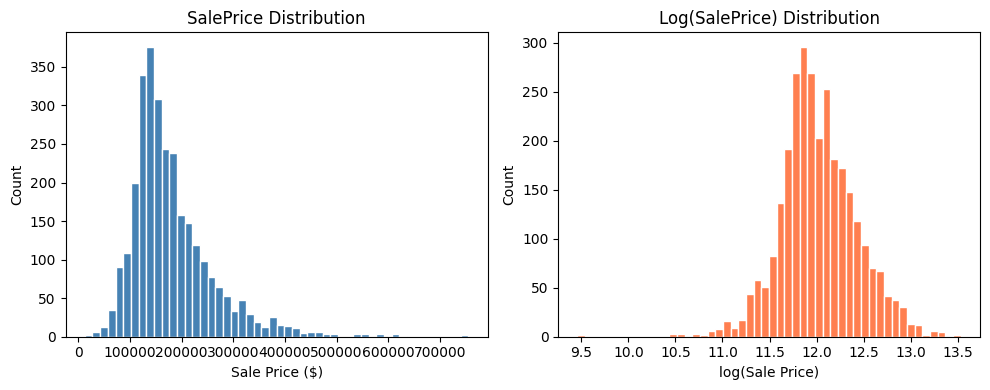

Skewness (original)     : 1.7456
Skewness (log-transform): -0.0131


In [35]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
plt.title('SalePrice Distribution')
plt.xlabel('Sale Price ($)')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
plt.hist(np.log(df['SalePrice']), bins=50, color='coral', edgecolor='white')
plt.title('Log(SalePrice) Distribution')
plt.xlabel('log(Sale Price)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

print(f"Skewness (original)     : {df['SalePrice'].skew():.4f}")
print(f"Skewness (log-transform): {np.log(df['SalePrice']).skew():.4f}")

In [36]:
df.shape

(2923, 78)

b. Descriptive analysis - Correlation Analysis

In [37]:
num_df = df.select_dtypes(include='number').drop(columns=['SalePrice'])

results = []
for col in num_df.columns:
    clean = df[['SalePrice', col]].dropna()
    r, p = stats.pearsonr(clean[col], clean['SalePrice'])
    results.append({'Feature': col, 'r': round(r, 4), 'p_value': p})

corr_df = (pd.DataFrame(results)
             .assign(abs_r=lambda x: x['r'].abs(),
                     Significant=lambda x: x['p_value'] < 0.05)
             .sort_values('abs_r', ascending=False))

sig_df = corr_df[corr_df['Significant']].reset_index(drop=True)

print(f"Total features tested  : {len(corr_df)}")
print(f"Significant (p < 0.05) : {len(sig_df)}")
print(f"\nTop 5:\n")
print(sig_df.head(5)[['Feature', 'r', 'p_value']].to_string(index=False))

Total features tested  : 56
Significant (p < 0.05) : 49

Top 5:

     Feature      r  p_value
    Total SF 0.8114      0.0
Overall Qual 0.8018      0.0
 Gr Liv Area 0.7184      0.0
  Exter Qual 0.7001      0.0
Kitchen Qual 0.6739      0.0


Five most important findings of house price determination

Finding 1

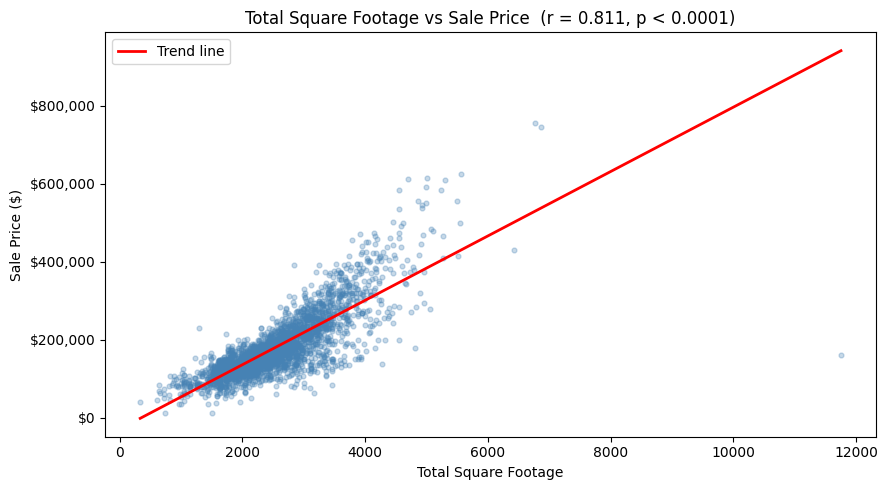

r = 0.811


In [38]:
#Total Square Footage
r1, p1 = stats.pearsonr(df['Total SF'], df['SalePrice'])

plt.figure(figsize=(9, 5))
plt.scatter(df['Total SF'], df['SalePrice'], alpha=0.3, s=12, color='steelblue')
m, b = np.polyfit(df['Total SF'], df['SalePrice'], 1)
x = np.linspace(df['Total SF'].min(), df['Total SF'].max(), 200)
plt.plot(x, m*x + b, color='red', linewidth=2, label='Trend line')
plt.title(f"Total Square Footage vs Sale Price  (r = {r1:.3f}, p < 0.0001)")
plt.xlabel("Total Square Footage")
plt.ylabel("Sale Price ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.legend()
plt.tight_layout()
plt.show()

print(f"r = {r1:.3f}")

Finding 2

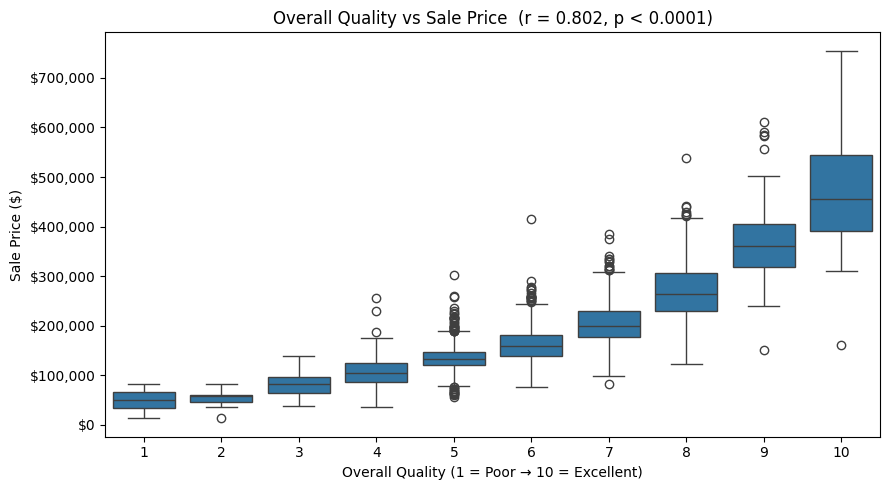

              Count    Mean  Median
Overall Qual                       
1                 4   48725   50150
2                13   52325   57625
3                40   83186   81200
4               225  106607  105000
5               822  134511  133000
6               732  162130  159500
7               602  205026  200000
8               349  270945  264561
9               107  368337  360000
10               29  468556  455000


In [39]:
#Overall Quality
r2, p2 = stats.pearsonr(df['Overall Qual'], df['SalePrice'])

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Overall Qual', y='SalePrice',
            order=sorted(df['Overall Qual'].unique()))
plt.title(f"Overall Quality vs Sale Price  (r = {r2:.3f}, p < 0.0001)")
plt.xlabel("Overall Quality (1 = Poor → 10 = Excellent)")
plt.ylabel("Sale Price ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

print(df.groupby('Overall Qual')['SalePrice']
        .agg(Count='count', Mean='mean', Median='median')
        .round(0).astype(int))

Finding 3

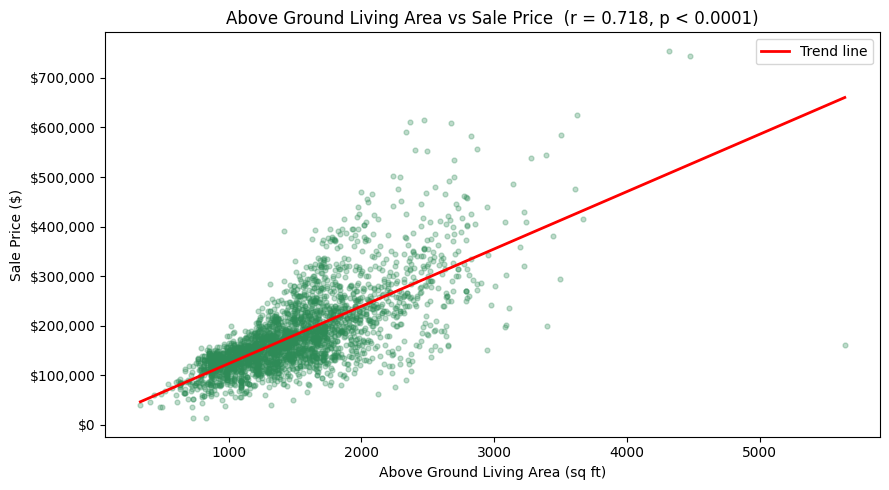

r = 0.718


In [40]:
#Above Ground Living Area
r3, p3 = stats.pearsonr(df['Gr Liv Area'], df['SalePrice'])

plt.figure(figsize=(9, 5))
plt.scatter(df['Gr Liv Area'], df['SalePrice'], alpha=0.3, s=12, color='seagreen')
m, b = np.polyfit(df['Gr Liv Area'], df['SalePrice'], 1)
x = np.linspace(df['Gr Liv Area'].min(), df['Gr Liv Area'].max(), 200)
plt.plot(x, m*x + b, color='red', linewidth=2, label='Trend line')
plt.title(f"Above Ground Living Area vs Sale Price  (r = {r3:.3f}, p < 0.0001)")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.legend()
plt.tight_layout()
plt.show()

print(f"r = {r3:.3f}")

Finding 4

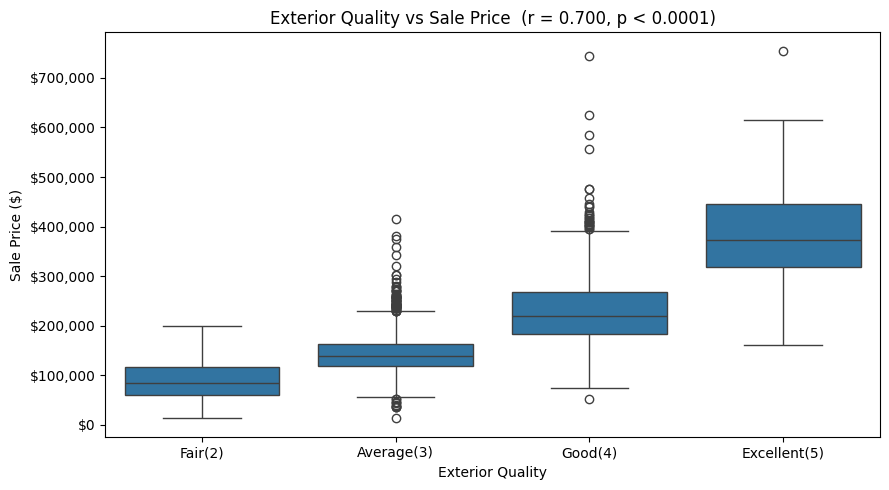

                  Count    Mean  Median
Exter Qual Label                       
Average(3)         1795  143313  139000
Excellent(5)        105  381607  372000
Fair(2)              35   89924   85000
Good(4)             988  230727  219355


In [41]:
# Exterior Quality
r4, p4 = stats.pearsonr(df['Exter Qual'], df['SalePrice'])

qual_labels = {1:'Poor(1)', 2:'Fair(2)', 3:'Average(3)', 4:'Good(4)', 5:'Excellent(5)'}
df['Exter Qual Label'] = df['Exter Qual'].map(qual_labels)
label_order = [qual_labels[i] for i in sorted(df['Exter Qual'].unique())]

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Exter Qual Label', y='SalePrice', order=label_order)
plt.title(f"Exterior Quality vs Sale Price  (r = {r4:.3f}, p < 0.0001)")
plt.xlabel("Exterior Quality")
plt.ylabel("Sale Price ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

print(df.groupby('Exter Qual Label')['SalePrice']
        .agg(Count='count', Mean='mean', Median='median')
        .round(0).astype(int))

Finding 5

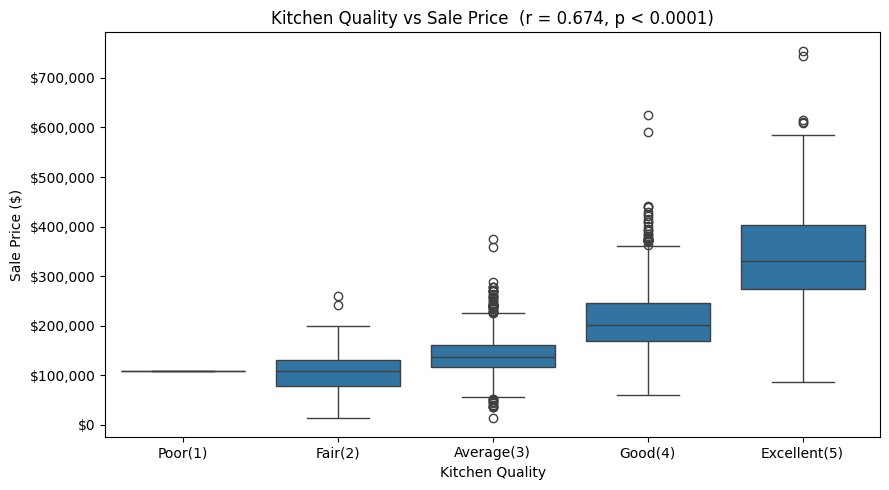

                    Count    Mean  Median
Kitchen Qual Label                       
Average(3)           1493  139591  136500
Excellent(5)          202  339115  330950
Fair(2)                70  105907  107750
Good(4)              1157  210882  201000
Poor(1)                 1  107500  107500


In [42]:
#Kitchen Quality
r5, p5 = stats.pearsonr(df['Kitchen Qual'], df['SalePrice'])

qual_labels = {1:'Poor(1)', 2:'Fair(2)', 3:'Average(3)', 4:'Good(4)', 5:'Excellent(5)'}
df['Kitchen Qual Label'] = df['Kitchen Qual'].map(qual_labels)
label_order = [qual_labels[i] for i in sorted(df['Kitchen Qual'].unique())]

plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Kitchen Qual Label', y='SalePrice', order=label_order)
plt.title(f"Kitchen Quality vs Sale Price  (r = {r5:.3f}, p < 0.0001)")
plt.xlabel("Kitchen Quality")
plt.ylabel("Sale Price ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

print(df.groupby('Kitchen Qual Label')['SalePrice']
        .agg(Count='count', Mean='mean', Median='median')
        .round(0).astype(int))

c. i. Multiple Linear Regression model

In [43]:
# Drop the label columns we created for plots
df = df.drop(columns=['Exter Qual Label', 'Kitchen Qual Label'])

# One-hot encode all remaining text columns
df_model = pd.get_dummies(df, drop_first=True)

print(f"Original shape : {df.shape}")
print(f"Model shape    : {df_model.shape}")

Original shape : (2923, 78)
Model shape    : (2923, 217)


In [44]:
# Log transform SalePrice (we confirmed above it is right skewed)
df_model['log_SalePrice'] = np.log(df_model['SalePrice'])

# X = everything except SalePrice and log_SalePrice
# y = log_SalePrice (what we want to predict)
X = df_model.drop(columns=['SalePrice', 'log_SalePrice'])
y = df_model['log_SalePrice']

# 70% train, 30% test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

print(f"Training rows : {X_train.shape[0]}")
print(f"Testing rows  : {X_test.shape[0]}")
print(f"Features      : {X_train.shape[1]}")

Training rows : 2046
Testing rows  : 877
Features      : 216


Scaling the features


In [45]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling done.")

Scaling done.


ii. Model Training

In [46]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV

# OLS
ols = LinearRegression()
ols.fit(X_train_scaled, y_train)
print(f"OLS   — Training R²: {ols.score(X_train_scaled, y_train):.4f}")

# Ridge
ridge = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge.fit(X_train_scaled, y_train)
print(f"Ridge — Training R²: {ridge.score(X_train_scaled, y_train):.4f}  |  best alpha: {ridge.alpha_:.4f}")

# LASSO
lasso = LassoCV(alphas=np.logspace(-4, 1, 100), cv=5, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
n_kept   = np.sum(lasso.coef_ != 0)
n_zeroed = np.sum(lasso.coef_ == 0)
print(f"LASSO — Training R²: {lasso.score(X_train_scaled, y_train):.4f}  |  best alpha: {lasso.alpha_:.4f}")
print(f"        Features kept: {n_kept}  |  Features zeroed: {n_zeroed}")

OLS   — Training R²: 0.9249
Ridge — Training R²: 0.9135  |  best alpha: 497.7024
LASSO — Training R²: 0.9109  |  best alpha: 0.0037
        Features kept: 82  |  Features zeroed: 134


d.Evaluation

In [47]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(model, X, y_log, name):
    y_pred = np.exp(model.predict(X))
    y_true = np.exp(y_log)
    return {
        'Model'   : name,
        'R²'      : round(r2_score(y_true, y_pred), 4),
        'RMSE ($)': round(np.sqrt(mean_squared_error(y_true, y_pred)), 0),
        'MAE ($)' : round(mean_absolute_error(y_true, y_pred), 0)
    }

results = pd.DataFrame([
    evaluate(ols,   X_test_scaled, y_test, 'OLS'),
    evaluate(ridge, X_test_scaled, y_test, 'Ridge'),
    evaluate(lasso, X_test_scaled, y_test, 'LASSO'),
]).set_index('Model')

print("Test Set Results")
print(results.to_string())

Test Set Results
           R²  RMSE ($)  MAE ($)
Model                           
OLS    0.9248   22698.0  14081.0
Ridge  0.9241   22806.0  13883.0
LASSO  0.9306   21814.0  13780.0
